In [1]:
import os                       # for working with files
import numpy as np              # for numerical computationss
import pandas as pd             # for working with dataframes
import torch                    # Pytorch module
import matplotlib.pyplot as plt # for plotting informations on graph and images using tensors
import torch.nn as nn           # for creating  neural networks
from torch.utils.data import DataLoader # for dataloaders
from PIL import Image           # for checking images
import torch.nn.functional as F # for functions for calculating loss
import torchvision.transforms as transforms   # for transforming images into tensors
from torchvision.utils import make_grid       # for data checking
from torchvision.datasets import ImageFolder  # for working with classes and images
from torchsummary import summary              # for getting the summary of our model
import torchvision.models as models

%matplotlib inline

In [2]:
data_dir = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
train_dir = os.path.join(data_dir, "train")
valid_dir = os.path.join(data_dir, "valid")
diseases = os.listdir(train_dir)
diseases

['Tomato___Late_blight',
 'Tomato___healthy',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Potato___healthy',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Tomato___Early_blight',
 'Tomato___Septoria_leaf_spot',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Strawberry___Leaf_scorch',
 'Peach___healthy',
 'Apple___Apple_scab',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Bacterial_spot',
 'Apple___Black_rot',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Peach___Bacterial_spot',
 'Apple___Cedar_apple_rust',
 'Tomato___Target_Spot',
 'Pepper,_bell___healthy',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Potato___Late_blight',
 'Tomato___Tomato_mosaic_virus',
 'Strawberry___healthy',
 'Apple___healthy',
 'Grape___Black_rot',
 'Potato___Early_blight',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Common_rust_',
 'Grape___Esca_(Black_Measles)',
 'Raspberry___healthy'

In [3]:
print(f"Total disease classes are: {len(diseases)}")

Total disease classes are: 38


In [4]:
plants = []
NumberOfDiseases = 0

for plant in diseases:
    if plant.split('___')[0] not in plants:
        plants.append(plant.split('___')[0])

    if plant.split('___')[1] != 'healthy':
        NumberOfDiseases += 1

In [5]:
print(f"Unique plants in the dataset: {plants}")

Unique plants in the dataset: ['Tomato', 'Grape', 'Orange', 'Soybean', 'Squash', 'Potato', 'Corn_(maize)', 'Strawberry', 'Peach', 'Apple', 'Blueberry', 'Cherry_(including_sour)', 'Pepper,_bell', 'Raspberry']


In [6]:
print(f"Number of plants are: {len(plants)}")

Number of plants are: 14


In [7]:
print(f"Number of unique disease: {NumberOfDiseases}")

Number of unique disease: 26


In [8]:
nums = {}

for disease in diseases:
    nums[disease] = len(os.listdir(train_dir + '/' + disease))

img_per_class = pd.DataFrame(nums.values(), index=nums.keys(), columns=["no. of images"])
img_per_class

,no. of images
Tomato___Late_blight,1851
Tomato___healthy,1926
Grape___healthy,1692
Orange___Haunglongbing_(Citrus_greening),2010
Soybean___healthy,2022
Squash___Powdery_mildew,1736
Potato___healthy,1824
Corn_(maize)___Northern_Leaf_Blight,1908
Tomato___Early_blight,1920
Tomato___Septoria_leaf_spot,1745


Text(0.5, 1.0, 'Images per each class of plant disease')

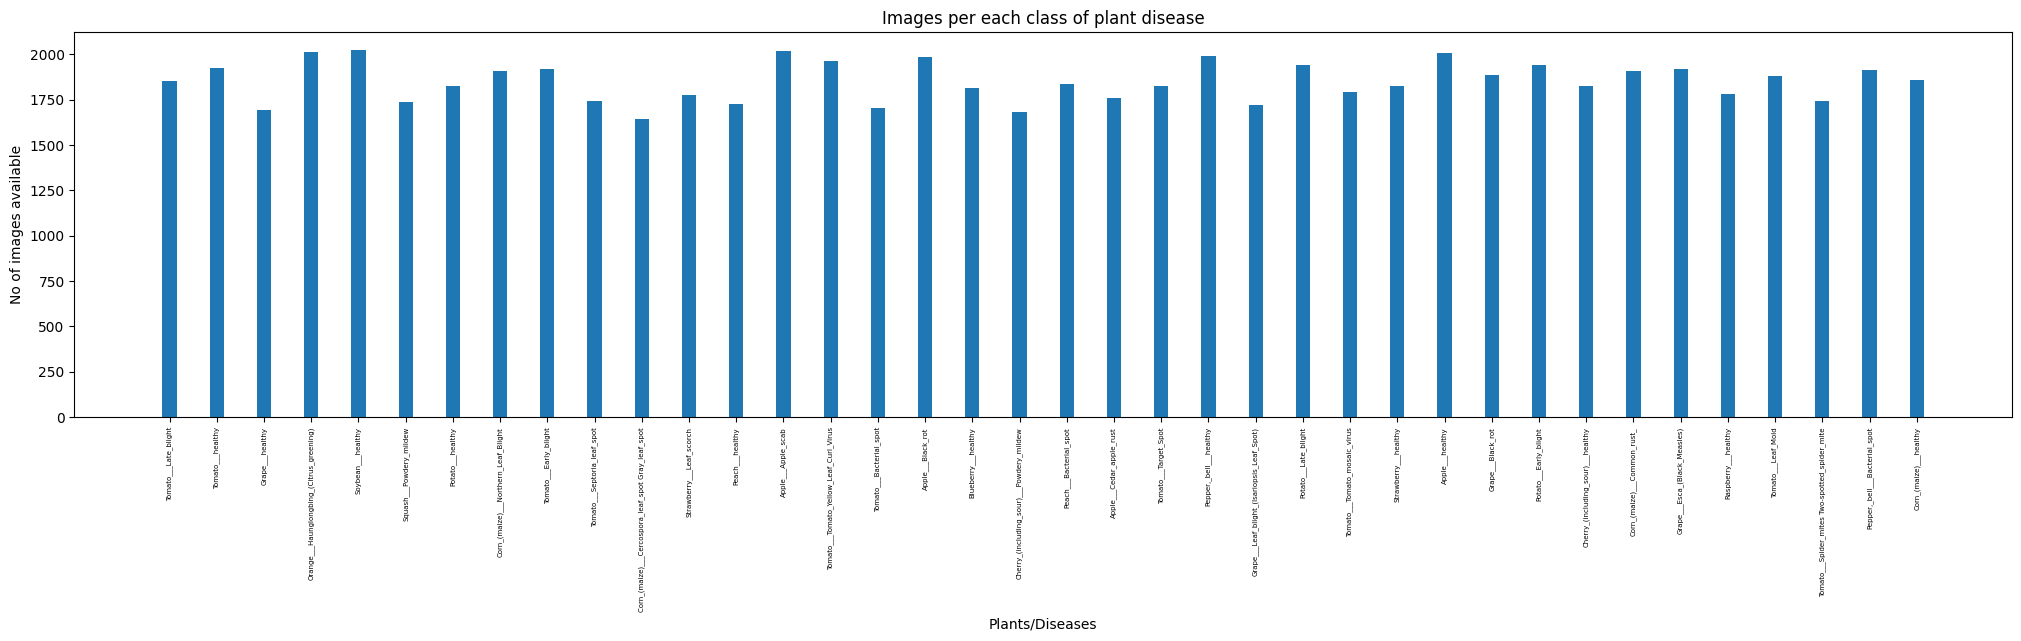

In [9]:
index = [n for n in range(38)]
plt.figure(figsize=(25, 5))
plt.bar(index, [n for n in nums.values()], width=0.3)
plt.xlabel('Plants/Diseases', fontsize=10)
plt.ylabel('No of images available', fontsize=10)
plt.xticks(index, diseases, fontsize=5, rotation=90)
plt.title('Images per each class of plant disease')

In [10]:
n_train = 0

for value in nums.values():
    n_train += value
print(f"There are {n_train} images for training")

There are 70295 images for training


In [11]:
transform = transforms.Compose([
    transforms.Resize((300, 300)),           # EfficientNet-B3 native size
    transforms.ToTensor(),
    transforms.Normalize(                    # ImageNet stats — required for pretrained
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:
train = ImageFolder(train_dir, transform=transform)
valid = ImageFolder(valid_dir, transform=transform)

In [13]:
img, label = train[0]
print(img.shape, label)

torch.Size([3, 300, 300]) 0


In [14]:
len(train.classes)

38

In [15]:
def show_image(image, label):
    print("Label :" + train.classes[label] + "(" + str(label) + ")")
    plt.imshow(image.permute(1, 2, 0))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7870152..2.0996952].


Label :Apple___Apple_scab(0)


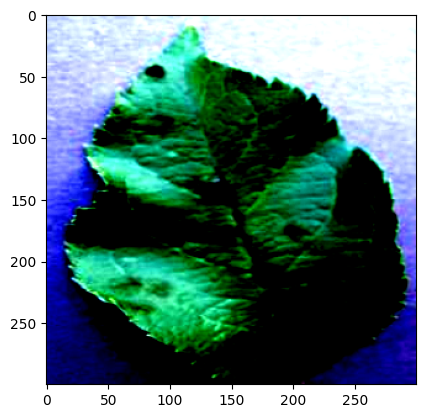

In [16]:
show_image(*train[0])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.5877128].


Label :Tomato___healthy(37)


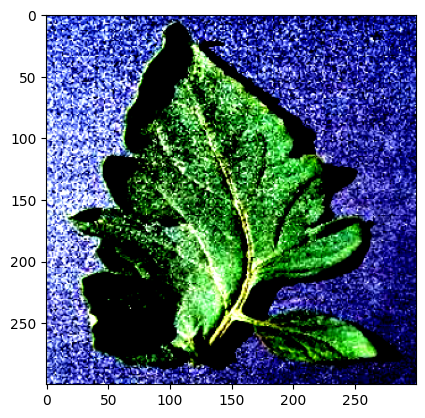

In [17]:
show_image(*train[70294])


In [18]:
random_seed = 7
torch.manual_seed(random_seed)

In [19]:
batch_size = 32


In [20]:
train_dl = DataLoader(train, batch_size, shuffle=True, num_workers=2, pin_memory=True)
valid_dl = DataLoader(valid, batch_size, num_workers=2, pin_memory=True)

In [21]:
def show_batch(data):
    for images, labels in data:
        fig, ax = plt.subplots(figsize=(30, 30))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(images, nrow=8).permute(1, 2, 0))
        break

In [22]:
# for moving data into GPU (if available)
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available:
        return torch.device("cuda")
    else:
        return torch.device("cpu")

# for moving data to device (CPU or GPU)
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

# for loading in the device (GPU if available else CPU)
class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
        
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)
        
    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [23]:
device = get_default_device()
device

device(type='cuda')

In [24]:
# Moving data into GPU
train_dl = DeviceDataLoader(train_dl, device)
valid_dl = DeviceDataLoader(valid_dl, device)

In [25]:
# for calculating the accuracy
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch
        out  = self(images)
        loss = F.cross_entropy(out, labels)
        return loss
    def validation_step(self, batch):
        images, labels = batch
        out  = self(images)
        loss = F.cross_entropy(out, labels)
        acc  = accuracy(out, labels)
        return {'val_loss': loss.detach(), 'val_accuracy': acc}
    def validation_epoch_end(self, outputs):
        batch_losses   = [x['val_loss']     for x in outputs]
        batch_accuracy = [x['val_accuracy'] for x in outputs]
        epoch_loss     = torch.stack(batch_losses).mean()
        epoch_accuracy = torch.stack(batch_accuracy).mean()
        return {'val_loss': epoch_loss, 'val_accuracy': epoch_accuracy}
    def epoch_end(self, epoch, result):
        print("Epoch [{}], last_lr: {:.5f}, train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['lrs'][-1], result['train_loss'],
            result['val_loss'], result['val_accuracy']))


In [26]:
class EfficientNetB3(ImageClassificationBase):
    def __init__(self, num_classes):
        super().__init__()

        # Load pretrained backbone
        self.network = models.efficientnet_b3(
            weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
        )

        # Replace the classifier head for 38 classes
        in_features = self.network.classifier[1].in_features   # 1536
        self.network.classifier = nn.Sequential(
            nn.Dropout(p=0.3, inplace=True),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, xb):
        return self.network(xb)

In [27]:
# defining the model and moving it to the GPU
model = to_device(EfficientNetB3(len(train.classes)), device)
model

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 181MB/s] 


EfficientNetB3(
  (network): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
              (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (sc

In [28]:
# getting summary of the model
INPUT_SHAPE = (3, 300, 300)
print(summary(model.network, INPUT_SHAPE))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 40, 150, 150]           1,080
       BatchNorm2d-2         [-1, 40, 150, 150]              80
              SiLU-3         [-1, 40, 150, 150]               0
            Conv2d-4         [-1, 40, 150, 150]             360
       BatchNorm2d-5         [-1, 40, 150, 150]              80
              SiLU-6         [-1, 40, 150, 150]               0
 AdaptiveAvgPool2d-7             [-1, 40, 1, 1]               0
            Conv2d-8             [-1, 10, 1, 1]             410
              SiLU-9             [-1, 10, 1, 1]               0
           Conv2d-10             [-1, 40, 1, 1]             440
          Sigmoid-11             [-1, 40, 1, 1]               0
SqueezeExcitation-12         [-1, 40, 150, 150]               0
           Conv2d-13         [-1, 24, 150, 150]             960
      BatchNorm2d-14         [-1, 24, 1

In [29]:
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)


def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']
    

def fit_OneCycle(epochs, max_lr, model, train_loader, val_loader, weight_decay=0,
                grad_clip=None, opt_func=torch.optim.SGD):
    torch.cuda.empty_cache()
    history = []
    
    optimizer = opt_func(model.parameters(), max_lr, weight_decay=weight_decay)
    # scheduler for one cycle learniing rate
    sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs, steps_per_epoch=len(train_loader))
    
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_losses = []
        lrs = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            
            # gradient clipping
            if grad_clip: 
                nn.utils.clip_grad_value_(model.parameters(), grad_clip)
                
            optimizer.step()
            optimizer.zero_grad()
            
            # recording and updating learning rates
            lrs.append(get_lr(optimizer))
            sched.step()
            
    
        # validation
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['lrs'] = lrs
        model.epoch_end(epoch, result)
        history.append(result)
        
    return history

In [30]:
%%time
history = [evaluate(model, valid_dl)]
history

CPU times: user 1min 18s, sys: 4.99 s, total: 1min 23s
Wall time: 1min 33s


[{'val_loss': tensor(3.6623, device='cuda:0'), 'val_accuracy': tensor(0.0185)}]

In [31]:
epochs = 3
max_lr = 0.001
grad_clip = 0.1
weight_decay = 1e-4
opt_func = torch.optim.Adam

In [32]:
%%time
history += fit_OneCycle(epochs, max_lr, model, train_dl, valid_dl, 
                             grad_clip=grad_clip, 
                             weight_decay=1e-4, 
                             opt_func=opt_func)

Epoch [0], last_lr: 0.00099, train_loss: 0.4657, val_loss: 0.0671, val_acc: 0.9793
Epoch [1], last_lr: 0.00046, train_loss: 0.0660, val_loss: 0.0221, val_acc: 0.9935
Epoch [2], last_lr: 0.00000, train_loss: 0.0118, val_loss: 0.0042, val_acc: 0.9990
CPU times: user 42min 7s, sys: 29min 12s, total: 1h 11min 19s
Wall time: 1h 10min 44s


In [33]:
def plot_accuracies(history):
    accuracies = [x['val_accuracy'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No. of epochs');

    
def plot_lrs(history):
    lrs = np.concatenate([x.get('lrs', []) for x in history])
    plt.plot(lrs)
    plt.xlabel('Batch no.')
    plt.ylabel('Learning rate')
    plt.title('Learning Rate vs. Batch no.');


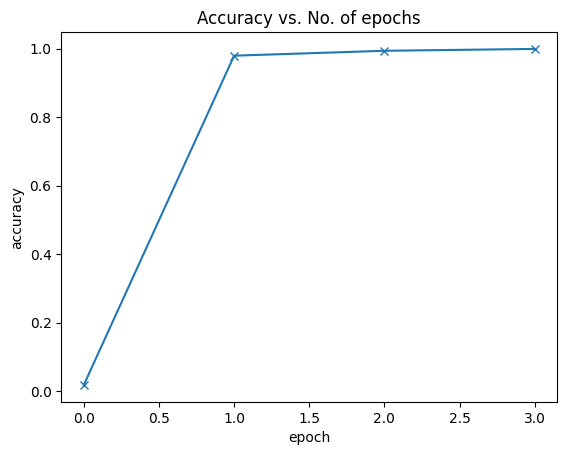

In [34]:
plot_accuracies(history)

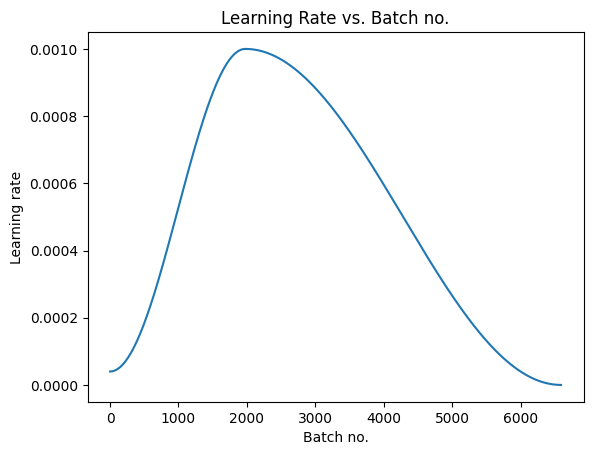

In [35]:
plot_lrs(history)

In [36]:
test_dir = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test"
test = ImageFolder(test_dir, transform=transforms.ToTensor())

In [37]:
test_images = sorted(os.listdir(test_dir + '/test')) # since images in test folder are in alphabetical order
test_images

['AppleCedarRust1.JPG',
 'AppleCedarRust2.JPG',
 'AppleCedarRust3.JPG',
 'AppleCedarRust4.JPG',
 'AppleScab1.JPG',
 'AppleScab2.JPG',
 'AppleScab3.JPG',
 'CornCommonRust1.JPG',
 'CornCommonRust2.JPG',
 'CornCommonRust3.JPG',
 'PotatoEarlyBlight1.JPG',
 'PotatoEarlyBlight2.JPG',
 'PotatoEarlyBlight3.JPG',
 'PotatoEarlyBlight4.JPG',
 'PotatoEarlyBlight5.JPG',
 'PotatoHealthy1.JPG',
 'PotatoHealthy2.JPG',
 'TomatoEarlyBlight1.JPG',
 'TomatoEarlyBlight2.JPG',
 'TomatoEarlyBlight3.JPG',
 'TomatoEarlyBlight4.JPG',
 'TomatoEarlyBlight5.JPG',
 'TomatoEarlyBlight6.JPG',
 'TomatoHealthy1.JPG',
 'TomatoHealthy2.JPG',
 'TomatoHealthy3.JPG',
 'TomatoHealthy4.JPG',
 'TomatoYellowCurlVirus1.JPG',
 'TomatoYellowCurlVirus2.JPG',
 'TomatoYellowCurlVirus3.JPG',
 'TomatoYellowCurlVirus4.JPG',
 'TomatoYellowCurlVirus5.JPG',
 'TomatoYellowCurlVirus6.JPG']

In [38]:
def predict_image(img, model):
    """Converts image to array and return the predicted class
        with highest probability"""
    # Convert to a batch of 1
    xb = to_device(img.unsqueeze(0), device)
    # Get predictions from model
    yb = model(xb)
    # Pick index with highest probability
    _, preds  = torch.max(yb, dim=1)
    # Retrieve the class label

    return train.classes[preds[0].item()]

Label: AppleCedarRust1.JPG , Predicted: Apple___Cedar_apple_rust


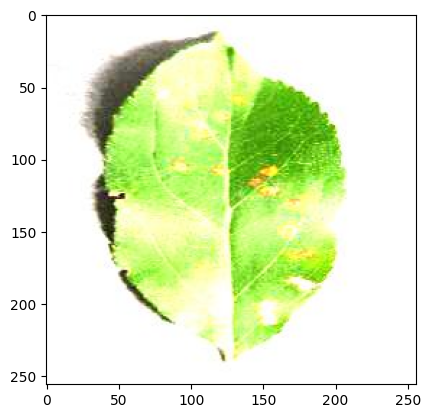

In [39]:
# predicting first image
img, label = test[0]
plt.imshow(img.permute(1, 2, 0))
print('Label:', test_images[0], ', Predicted:', predict_image(img, model))

In [40]:
# getting all predictions (actual label vs predicted)
for i, (img, label) in enumerate(test):
    print('Label:', test_images[i], ', Predicted:', predict_image(img, model))

Label: AppleCedarRust1.JPG , Predicted: Apple___Cedar_apple_rust
Label: AppleCedarRust2.JPG , Predicted: Apple___Cedar_apple_rust
Label: AppleCedarRust3.JPG , Predicted: Apple___Cedar_apple_rust
Label: AppleCedarRust4.JPG , Predicted: Apple___Cedar_apple_rust
Label: AppleScab1.JPG , Predicted: Apple___Cedar_apple_rust
Label: AppleScab2.JPG , Predicted: Apple___Cedar_apple_rust
Label: AppleScab3.JPG , Predicted: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Label: CornCommonRust1.JPG , Predicted: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Label: CornCommonRust2.JPG , Predicted: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Label: CornCommonRust3.JPG , Predicted: Corn_(maize)___Common_rust_
Label: PotatoEarlyBlight1.JPG , Predicted: Potato___Early_blight
Label: PotatoEarlyBlight2.JPG , Predicted: Potato___Early_blight
Label: PotatoEarlyBlight3.JPG , Predicted: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Label: PotatoEarlyBlight4.JPG , Predicted: Orange___Haunglon

In [41]:
# saving to the kaggle working directory
PATH = './plant-disease-model.pth'  
torch.save(model.state_dict(), PATH)

In [42]:
# saving the entire model to working directory
PATH = './plant-disease-model-complete.pth'
torch.save(model, PATH)

In [43]:
# ── NEW Cell 1: sklearn imports ────────────────────────────────
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)
import seaborn as sns

In [44]:
# ── NEW Cell 2: Collect all predictions from validation set ────
all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in valid_dl:
        outputs = model(images)
        _, preds = torch.max(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

import numpy as np
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
print(f'Collected {len(all_preds)} predictions')

Collected 17572 predictions


In [45]:
# ── NEW Cell 3: F1 / Precision / Recall ───────────────────────
precision = precision_score(all_labels, all_preds, average='weighted')
recall    = recall_score(all_labels,   all_preds, average='weighted')
f1        = f1_score(all_labels,       all_preds, average='weighted')

print('=' * 45)
print(f'  Weighted Precision : {precision*100:.2f}%')
print(f'  Weighted Recall    : {recall*100:.2f}%')
print(f'  Weighted F1-score  : {f1*100:.2f}%')
print('=' * 45)

short_names = [c.split('___')[1][:22] for c in train.classes]
print(classification_report(all_labels, all_preds,
                             target_names=short_names, digits=4))

  Weighted Precision : 99.90%
  Weighted Recall    : 99.90%
  Weighted F1-score  : 99.90%
                        precision    recall  f1-score   support

            Apple_scab     1.0000    1.0000    1.0000       504
             Black_rot     1.0000    1.0000    1.0000       497
      Cedar_apple_rust     1.0000    1.0000    1.0000       440
               healthy     1.0000    1.0000    1.0000       502
               healthy     1.0000    1.0000    1.0000       454
        Powdery_mildew     1.0000    1.0000    1.0000       421
               healthy     1.0000    1.0000    1.0000       456
Cercospora_leaf_spot G     0.9951    0.9902    0.9927       410
          Common_rust_     0.9979    0.9979    0.9979       477
  Northern_Leaf_Blight     0.9896    0.9937    0.9916       477
               healthy     1.0000    1.0000    1.0000       465
             Black_rot     0.9979    1.0000    0.9989       472
  Esca_(Black_Measles)     1.0000    0.9979    0.9990       480
Leaf_blight_(

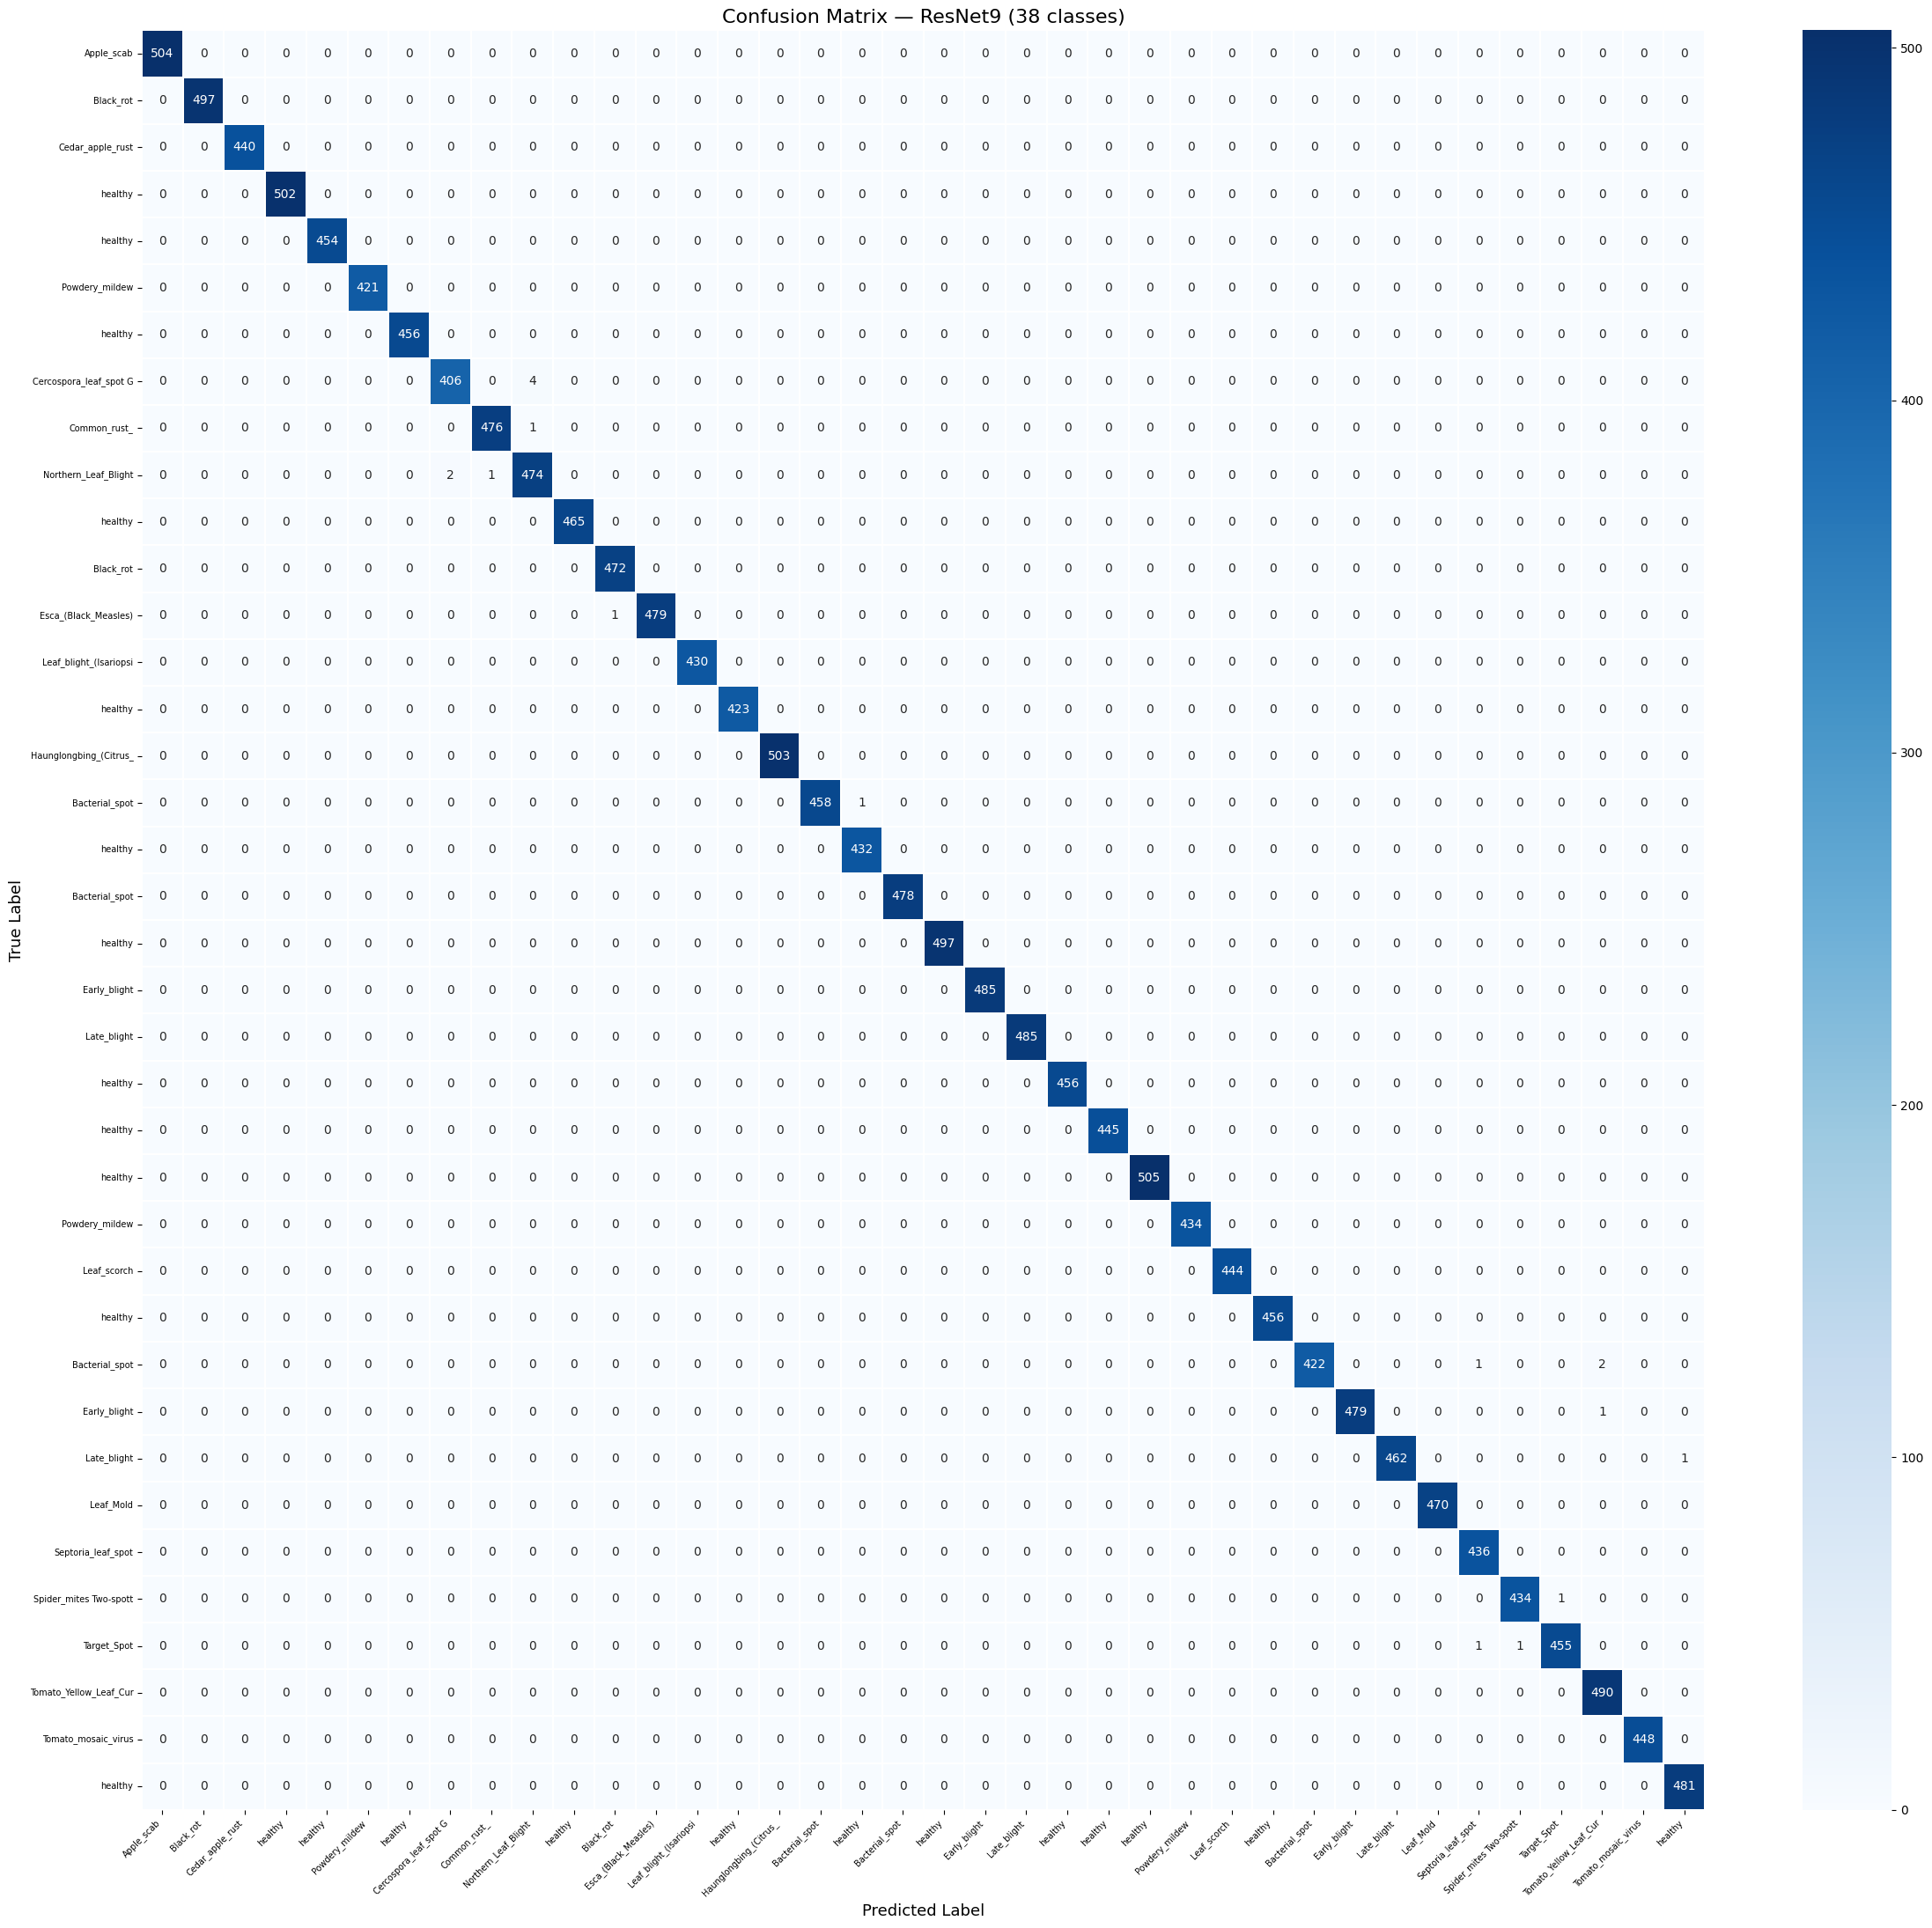

In [46]:
# ── NEW Cell 4: Confusion matrix heatmap ──────────────────────
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(24, 22))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names,
            yticklabels=short_names,
            linewidths=0.3, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label',      fontsize=13)
ax.set_title('Confusion Matrix — ResNet9 (38 classes)', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

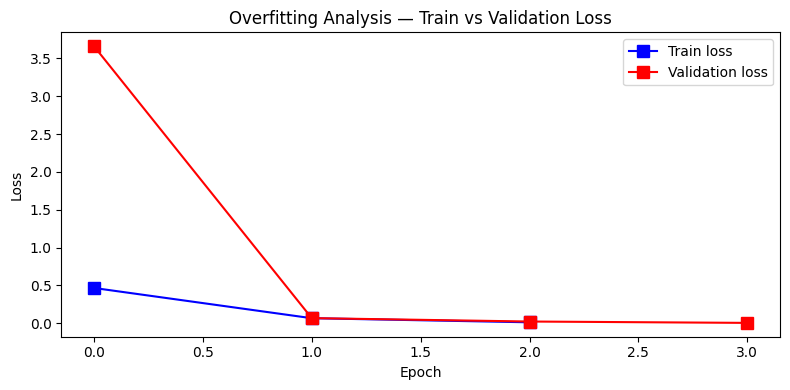

Final loss gap: 0.0076
No significant overfitting.


In [47]:
# ── NEW Cell 5: Overfitting analysis ──────────────────────────
train_losses = [x.get('train_loss') for x in history if x.get('train_loss')]
val_losses   = [x['val_loss'].item() if torch.is_tensor(x['val_loss'])
                else x['val_loss'] for x in history]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, '-bs', label='Train loss',      markersize=8)
ax.plot(val_losses,   '-rs', label='Validation loss', markersize=8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Overfitting Analysis — Train vs Validation Loss')
ax.legend()
plt.tight_layout()
plt.savefig('overfitting_analysis.png', dpi=120)
plt.show()

gap = abs(train_losses[-1] - val_losses[-1])
print(f'Final loss gap: {gap:.4f}')
print('No significant overfitting.' if gap < 0.1 else 'Possible overfitting detected.')